# 1) Load the data from the file and show: thefirst few rows, the output of the.describe() function, the number of rowsand columns

In [25]:
import pandas as pd
data = pd.read_csv("./exam_2021_01_27.csv", header=None)
display(data.head())
display(data.describe())
print(f"There are {data.shape[0]} rows and {data.shape[1]} columns")

,0,1,2,3,4
0,5.1,3.5,a,NaN,0
1,4.9,3.0,a,NaN,0
2,NaN,3.2,a,NaN,0
3,4.6,NaN,a,0.2,0
4,5.0,3.6,a,0.2,0


,0,1,3,4
count,141.000000,140.000000,137.000000,150.000000
mean,5.897872,3.036429,1.290511,1.000000
std,0.820232,0.437654,0.733934,0.819232
min,4.300000,2.000000,0.100000,0.000000
25%,5.200000,2.800000,0.400000,0.000000
50%,5.800000,3.000000,1.400000,1.000000
75%,6.400000,3.300000,1.800000,2.000000
max,7.900000,4.400000,2.500000,2.000000


There are 150 rows and 5 columns


# 2) Since the data contain nulls, eliminate therows with nulls

In [26]:
data.dropna(inplace=True)
display(data.head())
display(data.describe())
print(f"There are {data.shape[0]} rows and {data.shape[1]} columns")

,0,1,2,3,4
4,5.0,3.6,a,0.2,0
7,5.0,3.4,a,0.2,0
10,5.4,3.7,a,0.2,0
11,4.8,3.4,a,0.2,0
13,4.3,3.0,a,0.1,0


,0,1,3,4
count,122.000000,122.000000,122.000000,122.000000
mean,6.050000,2.985246,1.418852,1.229508
std,0.768088,0.433642,0.673136,0.736160
min,4.300000,2.000000,0.100000,0.000000
25%,5.500000,2.700000,1.100000,1.000000
50%,6.050000,3.000000,1.500000,1.000000
75%,6.500000,3.200000,1.900000,2.000000
max,7.900000,4.400000,2.500000,2.000000


There are 122 rows and 5 columns


# 3) Since one of the predicting attributes isordinal, it must be converted into numeric,you can use the OrdinalEncoder

In [27]:
from sklearn.preprocessing import OrdinalEncoder
data_encoded = pd.DataFrame(OrdinalEncoder().fit_transform(data))
data_encoded

,0,1,2,3,4
0,5.0,15.0,0.0,1.0,0.0
1,5.0,13.0,0.0,1.0,0.0
2,8.0,16.0,0.0,1.0,0.0
3,3.0,13.0,0.0,1.0,0.0
4,0.0,9.0,0.0,0.0,0.0
...,...,...,...,...,...
117,21.0,9.0,3.0,18.0,2.0
118,17.0,4.0,3.0,14.0,2.0
119,19.0,9.0,3.0,15.0,2.0
120,16.0,13.0,3.0,18.0,2.0


# 4) Split the data into trainand test

In [28]:
from sklearn.model_selection import train_test_split
random_state = 42

# Assume the 4th column to be the label
X = data_encoded.iloc[:,:-1]
y = data_encoded.iloc[:,-1]

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=random_state)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(91, 4) (31, 4) (91,) (31,)


# 5) Use two classification models of yourchoice (say: model 1 and model 2) executethe tasks below

In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "dt" : {
        "name" : "Decision Tree",
        "classifier" : DecisionTreeClassifier(random_state=random_state),
        "params" : {
            "criterion" : ["gini", "entropy", "log_loss"],
            "max_depth" : [*range(1,31)],
            "min_samples_split" : [*range(2,11)]
        }
    },
    "rf" : {
        "name" : "Random Forest",
        "classifier" : RandomForestClassifier(random_state=random_state, n_jobs=-1),
        "params" : {
            "n_estimators" : [*range(10, 101, 10)],
            "criterion" : ["gini", "entropy", "log_loss"],
            "max_depth" : [*range(1,21)]
        }
    }
}

# 6/8) Model 1/2: find and show the besthyperparameter setting with cross validationon the training set, optimise for the bestaccuracy

# 7/9) Model 1/2: show the accuracy ofclassification and the confusion matrix onthe test setFor the confusion matrix useplot_confusion_matrix normalized in orderto show for each class the precision (readcarefully the documentation)

Best parameters for Decision Tree : {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
Accuracy on test for Decision Tree : 87.097%


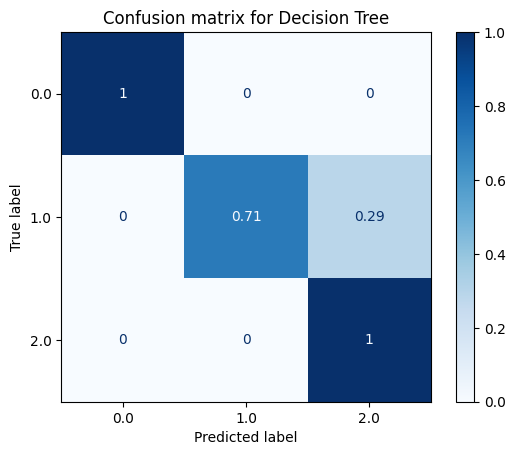

Best parameters for Random Forest : {'criterion': 'gini', 'max_depth': 3, 'n_estimators': 30}
Accuracy on test for Random Forest : 93.548%


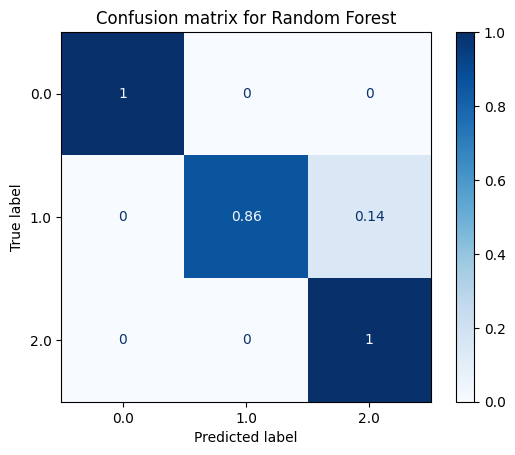

In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay 
import matplotlib.pyplot as plt

for k, model in models.items():
    
    # Find the best parameters
    search = GridSearchCV(
        estimator=model["classifier"],
        param_grid=model["params"],
        cv=5,
        n_jobs=-1,
        scoring="accuracy"
    ).fit(X_train, y_train)
    best_params = search.best_params_
    print(f"Best parameters for {model['name']} : {best_params}")
    
    # Show accuracy of classification
    best_model = model["classifier"].set_params(**best_params).fit(X_train,y_train)
    y_pred = best_model.predict(X_test)
    print(f"Accuracy on test for {model['name']} : {accuracy_score(y_test, y_pred)*100:.3f}%")
    
    # Plot the normalized confusion matrix
    disp = ConfusionMatrixDisplay.from_estimator(
        best_model,
        X_test,
        y_test,
        cmap=plt.cm.Blues,
        normalize="pred", # show precision
        # normalize="true", # show recall
        # normalize="all", # show accuracy
    )
    disp.ax_.set_title(f"Confusion matrix for {model['name']}")
    plt.show()